# Lab Exam Q1

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ensure_gray(image):
    if image is None:
        raise ValueError('Expected image input')
    if image.ndim == 2:
        return image
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def ensure_bgr(image):
    if image is None:
        raise ValueError('Expected image input')
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    if image.shape[2] == 4:
        return cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
    return image

def odd_ksize(value, minimum=1):
    k = int(value)
    k = max(int(minimum), k)
    if k % 2 == 0:
        k += 1
    return k

def gamma_correct(image, gamma):
    gamma = max(0.01, float(gamma))
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(image, table)

def show(image, title='Preview', figsize=(10, 6), cmap=None):
    plt.figure(figsize=figsize)
    if image.ndim == 2:
        plt.imshow(image, cmap=cmap or 'gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

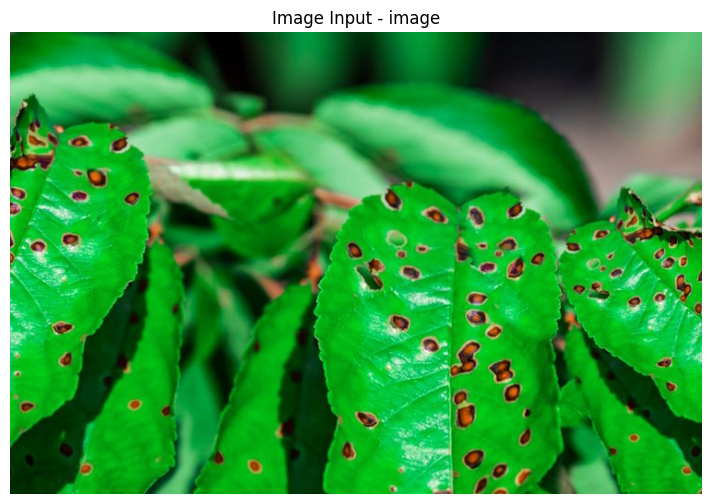

In [72]:
# Image Input (ImageInput)
image_path = 'brownleaf-1.jpg'
image_input = cv2.imread(image_path)
if image_input is None:
    raise FileNotFoundError(f'Unable to load image: {image_path}')

show(image_input, title='Image Input - image')

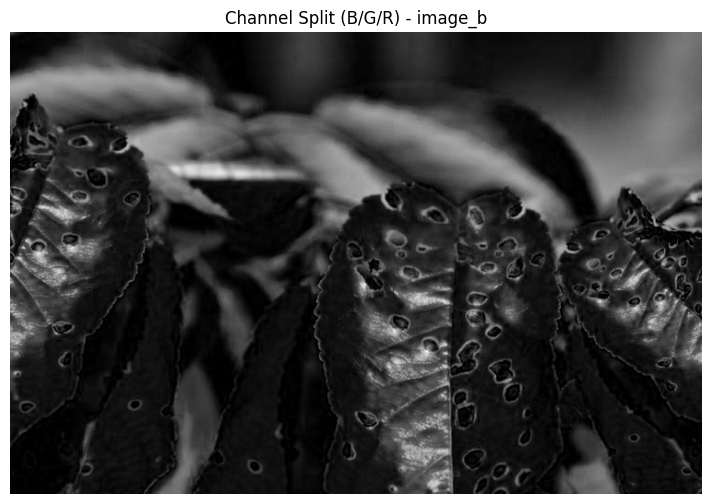

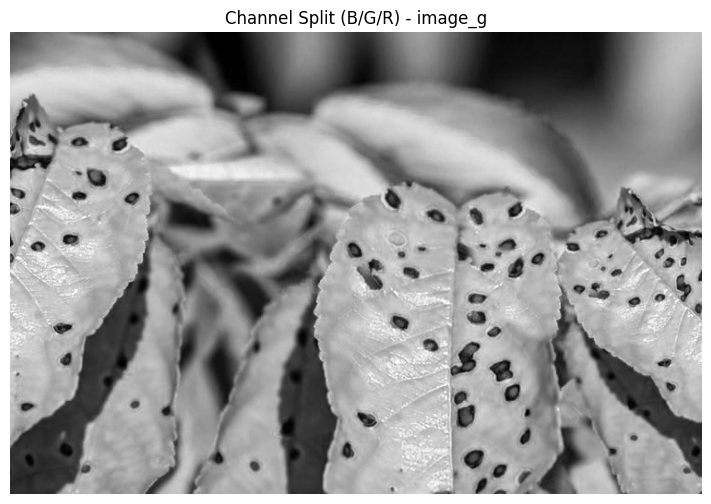

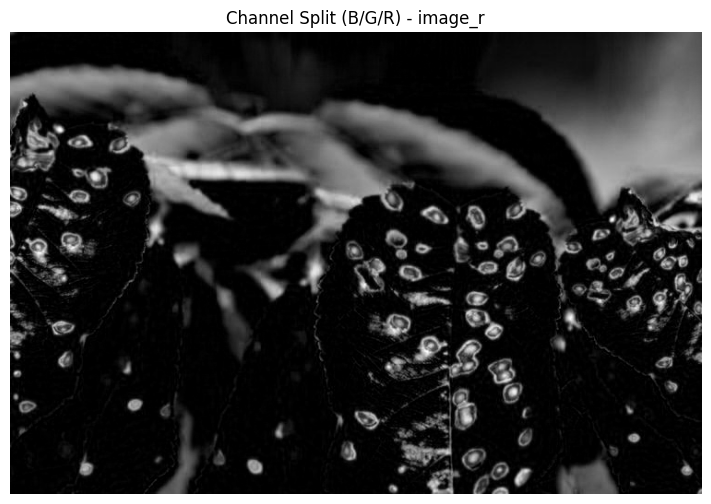

In [73]:
# Channel Split (B/G/R) (ChannelSplit)
_split_src = ensure_bgr(image_input)
_b, _g, _r = cv2.split(_split_src)
channel_split_b_g_r_image_b = cv2.cvtColor(_b, cv2.COLOR_GRAY2BGR)
channel_split_b_g_r_image_g = cv2.cvtColor(_g, cv2.COLOR_GRAY2BGR)
channel_split_b_g_r_image_r = cv2.cvtColor(_r, cv2.COLOR_GRAY2BGR)

show(channel_split_b_g_r_image_b, title='Channel Split (B/G/R) - image_b')
show(channel_split_b_g_r_image_g, title='Channel Split (B/G/R) - image_g')
show(channel_split_b_g_r_image_r, title='Channel Split (B/G/R) - image_r')

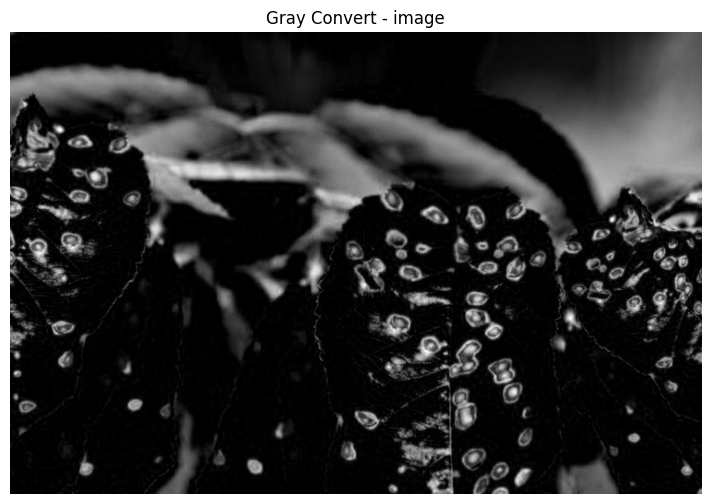

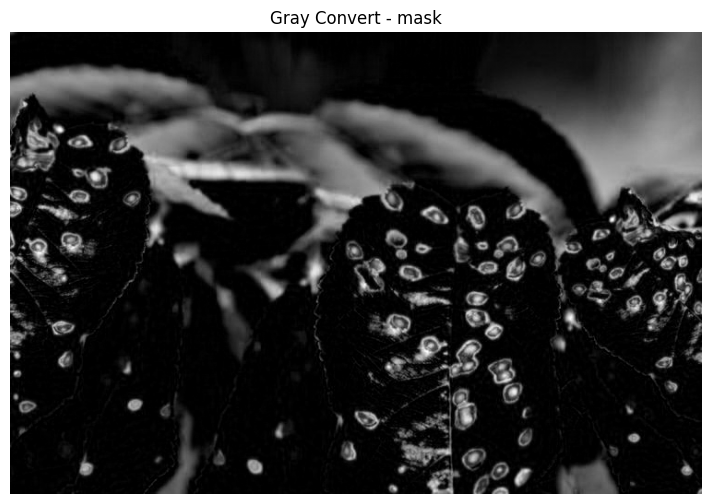

In [74]:
# Gray Convert (GrayConvert)
gray_convert_mask = ensure_gray(channel_split_b_g_r_image_r)
gray_convert_image = cv2.cvtColor(gray_convert_mask, cv2.COLOR_GRAY2BGR)

show(gray_convert_image, title='Gray Convert - image')
show(gray_convert_mask, title='Gray Convert - mask', cmap='gray')

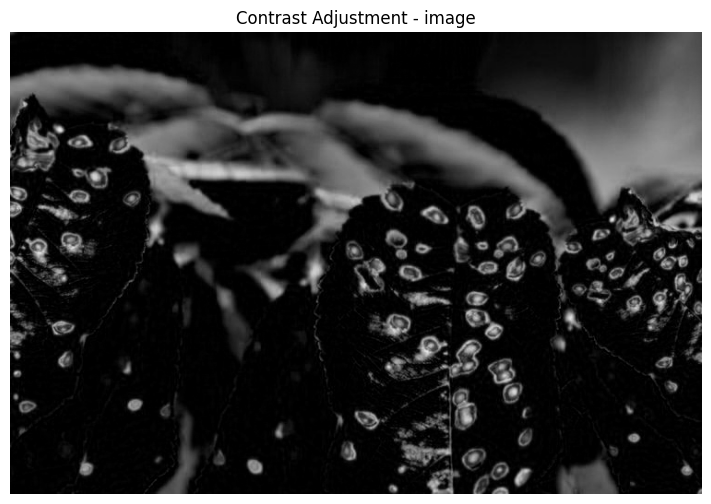

In [75]:
# Contrast Adjustment (ContrastAdjustment)
alpha = 0.8999999999999997
beta = 0
contrast_adjustment = cv2.convertScaleAbs(ensure_bgr(gray_convert_image), alpha=alpha, beta=beta)

show(contrast_adjustment, title='Contrast Adjustment - image')

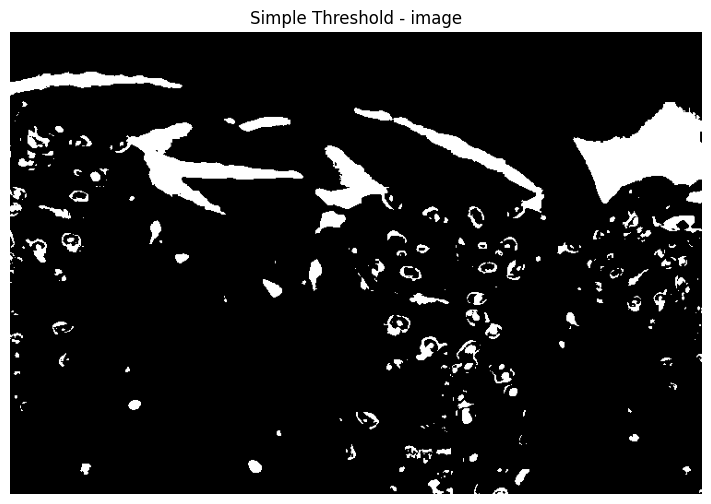

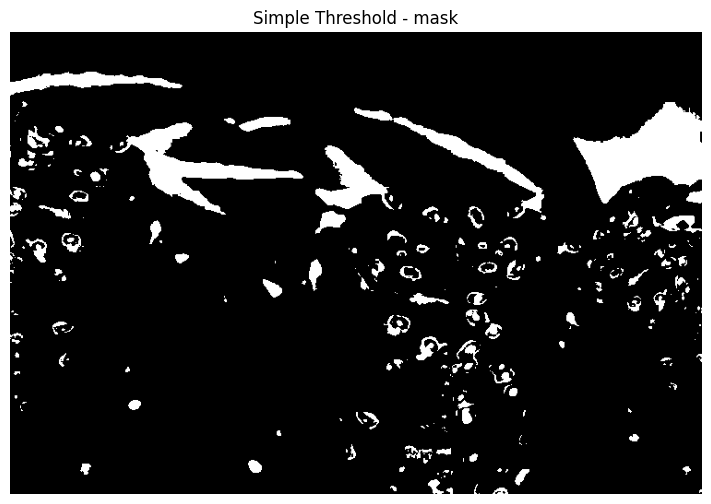

In [76]:
# Simple Threshold (SimpleThreshold)
_th_gray = ensure_gray(contrast_adjustment)
thresh = 117
max_value = 255
threshold_mode = cv2.THRESH_BINARY
pre_blur = odd_ksize(1, 1)
if pre_blur > 1:
    _th_gray = cv2.GaussianBlur(_th_gray, (pre_blur, pre_blur), 0)
if False:
    threshold_mode = threshold_mode | cv2.THRESH_OTSU
_, simple_threshold_mask = cv2.threshold(_th_gray, thresh, max_value, threshold_mode)
simple_threshold_image = cv2.cvtColor(simple_threshold_mask, cv2.COLOR_GRAY2BGR)

show(simple_threshold_image, title='Simple Threshold - image')
show(simple_threshold_mask, title='Simple Threshold - mask', cmap='gray')

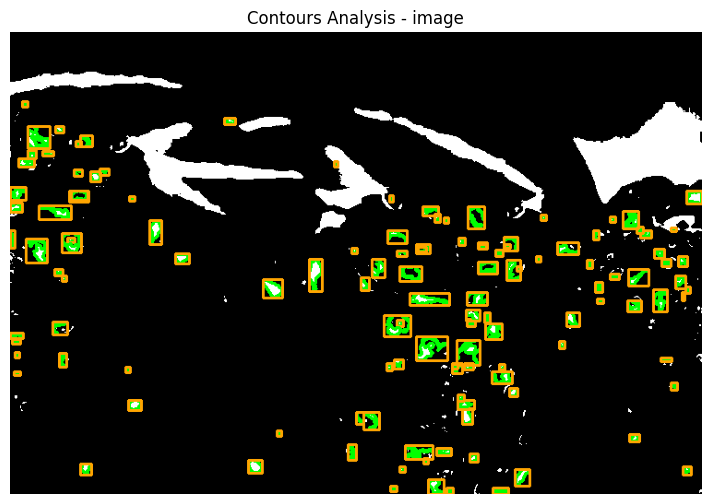

In [77]:
# Contours Analysis (ContoursAnalysis)
contours_analysis_mask = ensure_gray(simple_threshold_mask)
_, contours_analysis_mask = cv2.threshold(contours_analysis_mask, 0, 255, cv2.THRESH_BINARY)
_find_input = contours_analysis_mask.astype(np.int32) if cv2.RETR_TREE == cv2.RETR_FLOODFILL else contours_analysis_mask.copy()
_found = cv2.findContours(_find_input, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE, offset=(0, 0))
if len(_found) == 3:
    _, contours, hierarchy = _found
else:
    contours, hierarchy = _found
contours_analysis_image = cv2.cvtColor(contours_analysis_mask, cv2.COLOR_GRAY2BGR)
contours_analysis_detections = []
kept = 0
total_area = 0.0
rejected_area = 0
rejected_aspect = 0
for cnt in contours:
    area = float(cv2.contourArea(cnt))
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / float(h) if h > 0 else 9999.0
    perimeter = float(cv2.arcLength(cnt, True))
    if (area < 10 or area > 300):
        rejected_area += 1
        continue
    kept += 1
    total_area += area
    contours_analysis_detections.append({'bbox': (int(x), int(y), int(w), int(h)), 'label': 'contour', 'score': 1.0, 'extra': {'area': area, 'aspect_ratio': aspect_ratio, 'perimeter': perimeter}})
    if 'both' in ('contours', 'both'):
        cv2.drawContours(contours_analysis_image, [cnt], -1, (0, 255, 0), 2)
    if 'both' in ('boxes', 'both'):
        cv2.rectangle(contours_analysis_image, (x, y), (x + w, y + h), (0, 165, 255), 2)

show(contours_analysis_image, title='Contours Analysis - image')

In [78]:
draw_contours_on_original = ensure_bgr(image_input).copy()
draw_detections = contours_analysis_detections or []
show_label = False
show_score = False
for det in draw_detections:
    if isinstance(det, dict):
        x, y, w, h = det.get('bbox', (0, 0, 0, 0))
        label = str(det.get('label', 'obj'))
        score = float(det.get('score', 1.0))
    else:
        x, y, w, h = getattr(det, 'bbox', (0, 0, 0, 0))
        label = str(getattr(det, 'label', 'obj'))
        score = float(getattr(det, 'score', 1.0))
    x, y, w, h = int(x), int(y), int(w), int(h)
    cv2.rectangle(draw_contours_on_original, (x, y), (x + w, y + h), (0, 255, 0), 2)
    text = ''
    if show_label:
        text += label
    if show_score:
        text += (' ' if text else '') + f'{score:.2f}'
    if text:
        cv2.putText(draw_contours_on_original, text, (x, max(10, y - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1)


Contour count: 125


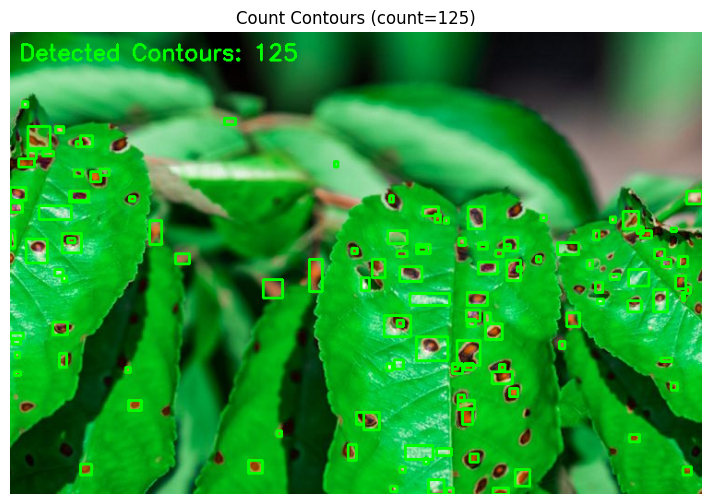

In [79]:
count_contours_image = ensure_bgr(draw_contours_on_original).copy()
count_contours_detections = list(contours_analysis_detections or [])
label_filter = 'contour'
exact_match = True
contour_count = 0
for _det in (contours_analysis_detections or []):
    if isinstance(_det, dict):
        _label = str(_det.get('label', ''))
    else:
        _label = str(getattr(_det, 'label', ''))
    if not label_filter:
        contour_count += 1
    elif exact_match and _label == label_filter:
        contour_count += 1
    elif (not exact_match) and label_filter.lower() in _label.lower():
        contour_count += 1
print(f'Contour count: {contour_count}')
if True:
    cv2.putText(count_contours_image, f"Detected Contours: {contour_count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
count_contours_meta = {
    'contour_count': contour_count,
    'label_filter': label_filter,
    'exact_match': exact_match,
    'total_detections': len(contours_analysis_detections or []),
}

show(count_contours_image, title=f"Count Contours (count={count_contours_meta.get('contour_count', 0)})")